# Scaling
- It is a crucial data preprocessing step that standardizes or normalizes the range of features, ensuring all input variables have a similar scale, which prevents features with larger magnitudes from dominating the learning process, leading to faster convergence, reduced bias, and improved model performance for algorithms.

- Common methods include Min-Max Scaling (0 to 1 range) and Standardization (mean 0, std dev 1), with Robust Scaling also used for outlier handling.

- Min-Max Scaling (Normalization):X_scaled= (X_i-X_min) /   (X_max-X_min)

- Standardization (Z-Score Scaling):z=(xi-mue) / sigma  where mue = mean, sigma = standard deviation

In [1]:
import numpy as np
import pandas as pd

# Dataset Link
https://www.kaggle.com/code/dhirajbembade/social-network-ads/notebook

In [3]:
df = pd.read_csv('Social_Network_Ads.csv')

In [4]:
df = df.iloc[:,2:]
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [7]:
df.shape

(400, 3)

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

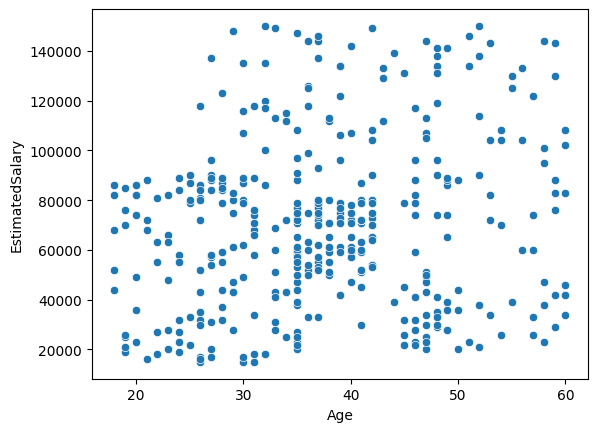

In [6]:
import seaborn as sns
sns.scatterplot(x=df.iloc[:,0],y=df.iloc[:,1])

In [8]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [10]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [11]:
model = Sequential()

model.add(Dense(128, activation='relu', input_dim=2))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [15]:
history = model.fit(X_train, y_train, validation_data=(X_test,y_test), epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.5747 - loss: 437.1154 - val_accuracy: 0.6000 - val_loss: 368.7633
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6018 - loss: 242.6824 - val_accuracy: 0.6000 - val_loss: 102.7840
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5646 - loss: 84.9514 - val_accuracy: 0.6000 - val_loss: 134.6496
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5949 - loss: 63.3412 - val_accuracy: 0.4000 - val_loss: 50.1789
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4626 - loss: 55.8731 - val_accuracy: 0.4000 - val_loss: 21.6002
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4213 - loss: 43.4342 - val_accuracy: 0.6000 - val_loss: 76.6717
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5097 - loss: 76.8293 - val_accuracy: 0.6000 - val_loss: 205.7847
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5723 - loss: 134.0157 

# Unnormalized Inputs

### What is the reason behind this irregularities or Inconsistancy?
- feature are not on same scale -> training oscilates a lot that's why it shows us spikey nature which is mostly beneficial for Non-Convex functions.

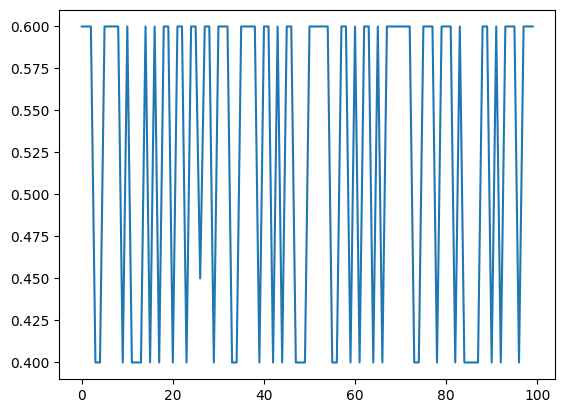

In [16]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])

# Normalized Inputs or Apply Scaling
- In this Features are on same scale  

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
# First 5
X_train_scaled[:5], X_test_scaled[:5]

(array([[ 0.88928823, -0.65924556],
        [-0.17254846,  0.87392651],
        [-1.04132394, -0.36440478],
        [ 0.98581884,  0.6085698 ],
        [-0.94479333,  0.57908572]]),
 array([[-0.84826272,  0.40218125],
        [-1.62050759, -1.57325199],
        [-0.07601785, -0.48234109],
        [-0.84826272,  0.16630863],
        [ 1.56500249,  0.01888824]]))

<Axes: >

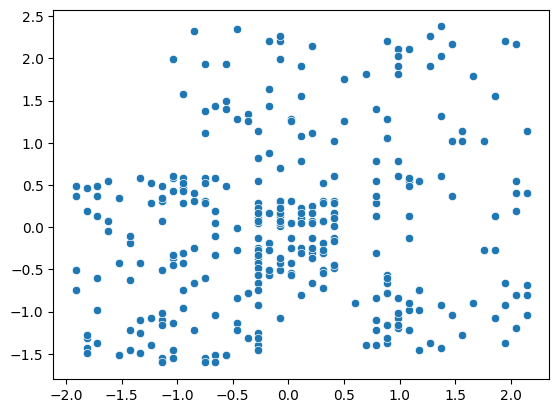

In [26]:
sns.scatterplot(x=X_train_scaled[:,0],y=X_train_scaled[:,1])

In [18]:
model = Sequential()

model.add(Dense(128, activation='relu', input_dim=2))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [30]:
history = model.fit(X_train_scaled, y_train, validation_data=(X_test_scaled,y_test), epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6517 - loss: 0.6617 - val_accuracy: 0.6250 - val_loss: 0.6085
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6294 - loss: 0.6119 - val_accuracy: 0.7250 - val_loss: 0.4992
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7385 - loss: 0.4917 - val_accuracy: 0.7750 - val_loss: 0.4167
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8151 - loss: 0.3982 - val_accuracy: 0.8000 - val_loss: 0.3692
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8227 - loss: 0.3627 - val_accuracy: 0.8000 - val_loss: 0.3460
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8740 - loss: 0.3236 - val_accuracy: 0.8250 - val_loss: 0.3371
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8581 - loss: 0.3377 - val_accuracy: 0.8250 - val_loss: 0.3363
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8771 - loss: 0.3340 - val_accuracy: 0.

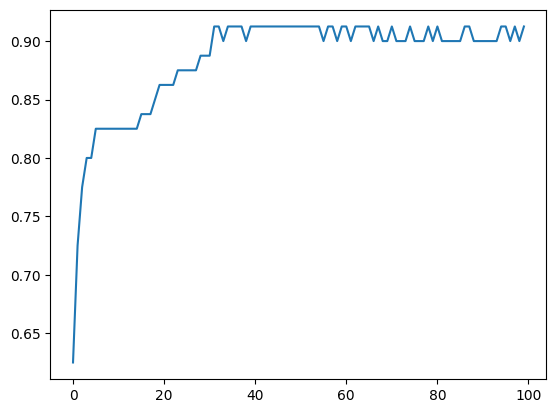

In [31]:
plt.plot(history.history['val_accuracy'])